# Data anlysis of ubi result

This notebook contains the data analysis of the ubiquitin dataset from the MaxSBM runs. A comparison is done between the introduced module and the standard MaxQuant version.  

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

# Importing the data

In [2]:
root_dir = '../ubi_review'
fig_dir = '../ubi_review/'


In [3]:
dfs = []
delimiters = ['_st_o', '_3_o', 'ESTLHLVLRLRGG']  # Add other delimiters as needed , 'Ubi(Protein N-term)','_o', '(K)', '_st',

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file) 

            # Get the parent directory one level up
            #parent_folder = os.path.basename(os.path.dirname(subdir))
            rel_path = os.path.relpath(subdir, root_dir)
            parent_folder = rel_path.split(os.sep)[0]
            print(parent_folder)
            
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'Ubi' or 'ESTLHLVLRLRGG' in col:
                    for delimiter in delimiters:
                        if delimiter in col:
                            new_col_name = 'Ubi' + col.split(delimiter, 1)[1]
                            print(new_col_name)
                            new_columns[col] = new_col_name

            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

# big_df.to_csv('/path/to/save/combined_file.txt', sep="\t", index=False)

Standard


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_21580/3454554519.py:15: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


Ubi Probabilities
Ubi Score diffs
Ubi
Ubi K
Ubi site IDs
SBM 3


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_21580/3454554519.py:15: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


Ubi Probabilities
Ubi Score diffs
Ubi
Ubi K
Ubi site IDs


# Some overall preproseccing steps

In [5]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)

big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'es|Ubi_3_o|Ubi_4_o|Ubi_st|Ubi_st_o|ubi_o|Ubi-ESTLHLVLRLRGG', 'ubi', regex=True)

In [7]:
big_df['Masses'] = big_df['Masses'].astype(str)
big_df['Intensities'] = big_df['Intensities'].astype(str)
big_df['Matches'] = big_df['Matches'].astype(str)

big_df['Masses'] = big_df['Masses'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Intensities'] = big_df['Intensities'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Matches'] = big_df['Matches'].apply(lambda x: [val for val in x.split(';')])

# Seperating data into diffrent sets

In [8]:
# ubi dataset 
df_ubi = big_df[(big_df['Ubi'] == 1)] 
df_no_ubi = big_df[(big_df['Ubi'] == 0) ]
df_ubi_more = big_df[(big_df['Ubi'] > 1) ] 

In [9]:
# unique sites and peptides  
df_ubi_unique = df_ubi.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)
df_unique = df_no_ubi.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)

# Visualisations

# For non ubiquitinated peptides

In [10]:
filtered_big_df_no_ubi = df_no_ubi[df_no_ubi['Reverse'] != '+']
filtered_counts_no_ubi = filtered_big_df_no_ubi.groupby('Dataset').size()

filtered_big_df_unique_peps = df_unique[df_unique['Reverse'] != '+']
filtered_counts_unique_peps = filtered_big_df_unique_peps.groupby('Dataset').size()

In [11]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['Standard', 'SBM 3']

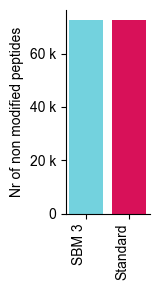

In [26]:
fig, ax = plt.subplots(figsize=(1.7, 3))
bars = ax.bar(filtered_counts_no_ubi.index, filtered_counts_no_ubi.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_no_ubi.index])

ax.set_ylabel('Nr of non modified peptides')
ax.set_xticks(filtered_counts_no_ubi.index) 
ax.set_xticklabels(filtered_counts_no_ubi.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show() 

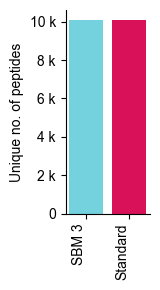

In [29]:
fig, ax = plt.subplots(figsize=(1.7, 3))

bars_un = ax.bar(filtered_counts_unique_peps.index, filtered_counts_unique_peps.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique_peps.index])


ax.set_ylabel('Unique no. of peptides')
ax.set_xticks(filtered_counts_unique_peps.index) 
ax.set_xticklabels(filtered_counts_unique_peps.index, ha='right',rotation=90)  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

# For ubiquitinylated peptides

In [15]:
filtered_big_df_ubi = df_ubi[df_ubi['Reverse'] != '+']
filtered_counts = filtered_big_df_ubi.groupby('Dataset').size()

filtered_big_df_moreubi = df_ubi_more[df_ubi_more['Reverse'] != '+']
filtered_counts_moreubi = filtered_big_df_moreubi.groupby('Dataset').size()

filtered_big_df_unique = df_ubi_unique[df_ubi_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique.groupby('Dataset').size()

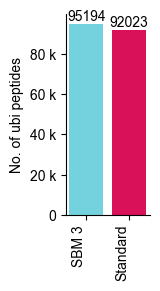

In [30]:
fig, ax =  plt.subplots(figsize=(1.7, 3))
bars = ax.bar(filtered_counts.index, filtered_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts.index])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_ylabel('No. of ubi peptides')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
#ax.set_ylim(0, 40000)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
#plt.savefig("")
file_path = fig_dir + "ubi_optimised.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

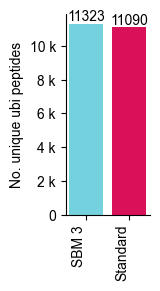

In [31]:
fig, ax = plt.subplots(figsize=(1.7, 3))
bars_un = ax.bar(filtered_counts_unique.index, filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index])

ax.set_ylabel('No. unique ubi peptides')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.set_ylim(0, 5000)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')
    
plt.tight_layout()
file_path = fig_dir + "ubi_optimised_unique.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_21580/1956653176.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)


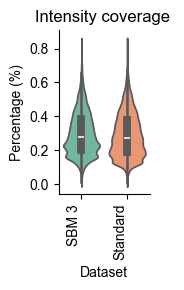

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_21580/1956653176.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)


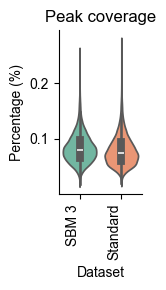

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_21580/1956653176.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)


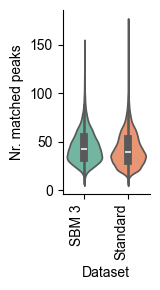

In [21]:
Intensity = filtered_big_df_ubi.pivot(columns='Dataset', values='Intensity coverage')

fig, ax = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=Intensity, ax=ax, palette="Set2")
ax.set_title('Intensity coverage ')
ax.set_ylabel('Percentage (%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)
plt.tight_layout()
file_path = fig_dir + "ubi_intensity_coverage_violin.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

Peak = filtered_big_df_ubi.pivot(columns='Dataset', values='Peak coverage')
fig, ax = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=Peak, ax=ax, palette="Set2")
ax.set_title('Peak coverage')
ax.set_ylabel('Percentage (%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)
plt.tight_layout()
file_path = fig_dir + "ubi_peak_coverage_violin.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

matches = filtered_big_df_ubi.pivot(columns='Dataset', values='Number of matches')
fig, ax = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=matches, ax=ax, palette="Set2")
ax.set_title('')
ax.set_ylabel('Nr. matched peaks')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=90)
plt.tight_layout()
file_path = fig_dir + "ubi_matched_peaks_violin.pdf"
plt.savefig(file_path, transparent=True)
plt.show()